# Online Retail — Data Cleaning & Visualization
Internship task: clean a raw e-commerce transactions dataset (missing values, duplicates, outliers) then visualize key business insights.

**Dataset:** `Online_Retail.xlsx` — 541,909 rows x 8 columns, UK-based online gift retailer, Dec 2010 – Dec 2011.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## Step 1 — Load the raw data

In [2]:
df = pd.read_excel("Online_Retail.xlsx")
print(f"Raw shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Raw shape: 541,909 rows x 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Step 2 — Missing value audit

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing": missing, "pct": missing_pct})[missing > 0]

,missing,pct
Description,1454,0.27
CustomerID,135080,24.93


## Step 3 — Handle missing values

- **`Description`** (0.27% missing) — filled with a placeholder; it's a text field not used in any calculation, so dropping rows would needlessly discard valid revenue records.
- **`CustomerID`** (25% missing) — these are guest checkouts, not bad data. Kept for revenue/product analysis, excluded later from customer-level analysis (top customers, RFM, etc).

In [4]:
df["Description"] = df["Description"].fillna("UNKNOWN ITEM")
df["CustomerID"] = df["CustomerID"].astype("Int64")  # nullable int
print(f"Rows with no CustomerID (guest orders): {df['CustomerID'].isnull().sum():,}")

Rows with no CustomerID (guest orders): 135,080


## Step 4 — Remove duplicate rows

In [5]:
dupes = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Removed {dupes:,} exact duplicate rows. New shape: {df.shape}")

Removed 5,268 exact duplicate rows. New shape: (536641, 8)


## Step 5 — Handle cancellations and invalid rows

`InvoiceNo` starting with `"C"` marks a cancellation (paired with a negative quantity). These are a real business signal (return rate), so they're split into their own frame rather than deleted outright.

In [6]:
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
is_cancellation = df["InvoiceNo"].str.startswith("C")
cancellations = df[is_cancellation].copy()
df_sales = df[~is_cancellation].copy()
print(f"Cancellations split out: {len(cancellations):,} ({len(cancellations)/len(df)*100:.1f}% of rows)")

Cancellations split out: 9,251 (1.7% of rows)


In [7]:
# Remove non-positive Quantity/UnitPrice (data entry errors, not real sales)
bad_qty = (df_sales["Quantity"] <= 0).sum()
bad_price = (df_sales["UnitPrice"] <= 0).sum()
df_sales = df_sales[(df_sales["Quantity"] > 0) & (df_sales["UnitPrice"] > 0)]
print(f"Removed {bad_qty:,} rows with Quantity<=0, {bad_price:,} rows with UnitPrice<=0")

# Remove non-product stock codes (postage, fees, manual adjustments)
junk_codes = ["POST", "D", "DOT", "M", "S", "AMAZONFEE", "BANK CHARGES", "CRUK", "PADS", "C2"]
before = len(df_sales)
df_sales = df_sales[~df_sales["StockCode"].isin(junk_codes)]
print(f"Removed {before - len(df_sales):,} rows with non-product StockCodes")

Removed 1,336 rows with Quantity<=0, 2,512 rows with UnitPrice<=0
Removed 2,308 rows with non-product StockCodes


## Step 6 — Outlier handling (IQR method)

Used IQR bounds on `Quantity` and `UnitPrice`, with a **wider multiplier (k=3 instead of the usual 1.5)** — this is a wholesale/gift retailer, so legitimate bulk orders are part of the business, not noise. k=3 trims only the extreme long tail (likely data-entry errors) while preserving real bulk-order behaviour.

In [8]:
df_sales["TotalPrice"] = df_sales["Quantity"] * df_sales["UnitPrice"]

def iqr_bounds(series, k=3.0):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

q_low, q_high = iqr_bounds(df_sales["Quantity"])
p_low, p_high = iqr_bounds(df_sales["UnitPrice"])

before = len(df_sales)
df_sales = df_sales[
    (df_sales["Quantity"].between(q_low, q_high)) &
    (df_sales["UnitPrice"].between(max(p_low, 0), p_high))
]
print(f"Quantity bounds: [{q_low:.1f}, {q_high:.1f}]  |  UnitPrice bounds: [{max(p_low,0):.2f}, {p_high:.2f}]")
print(f"Removed {before - len(df_sales):,} extreme outlier rows")

Quantity bounds: [-32.0, 45.0]  |  UnitPrice bounds: [0.00, 12.77]
Removed 29,288 extreme outlier rows


## Step 7 — Feature engineering

In [9]:
df_sales["InvoiceDate"] = pd.to_datetime(df_sales["InvoiceDate"])
df_sales["Year"] = df_sales["InvoiceDate"].dt.year
df_sales["Month"] = df_sales["InvoiceDate"].dt.month
df_sales["YearMonth"] = df_sales["InvoiceDate"].dt.to_period("M").astype(str)
df_sales["DayOfWeek"] = df_sales["InvoiceDate"].dt.day_name()
df_sales["Hour"] = df_sales["InvoiceDate"].dt.hour

print(f"Final cleaned dataset: {df_sales.shape[0]:,} rows ({df_sales.shape[0]/len(df)*100:.1f}% of pre-dedup rows retained)")
df_sales.head()

Final cleaned dataset: 493,282 rows (91.9% of pre-dedup rows retained)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,YearMonth,DayOfWeek,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,2010-12,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,2010-12,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,2010-12,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,2010-12,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,2010-12,Wednesday,8


In [10]:
df_sales.to_csv("cleaned_online_retail.csv", index=False)
print("Saved cleaned_online_retail.csv")

Saved cleaned_online_retail.csv


---
## Visualizations

### 1. Monthly Revenue Trend

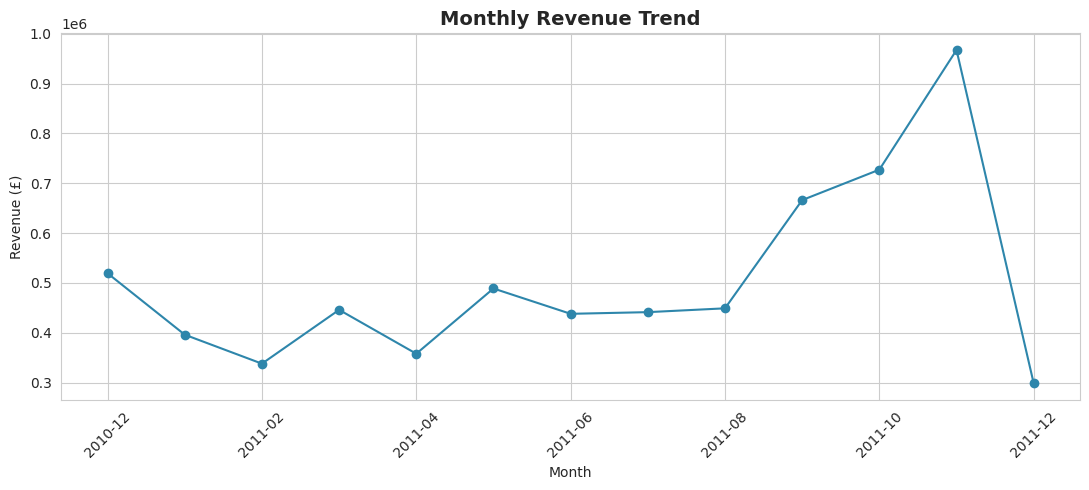

In [11]:
monthly_rev = df_sales.groupby("YearMonth")["TotalPrice"].sum().sort_index()

plt.figure(figsize=(11, 5))
monthly_rev.plot(kind="line", marker="o", color="#2E86AB")
plt.title("Monthly Revenue Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month"); plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("01_monthly_revenue_trend.png")
plt.show()

### 2. Top 10 Countries by Revenue

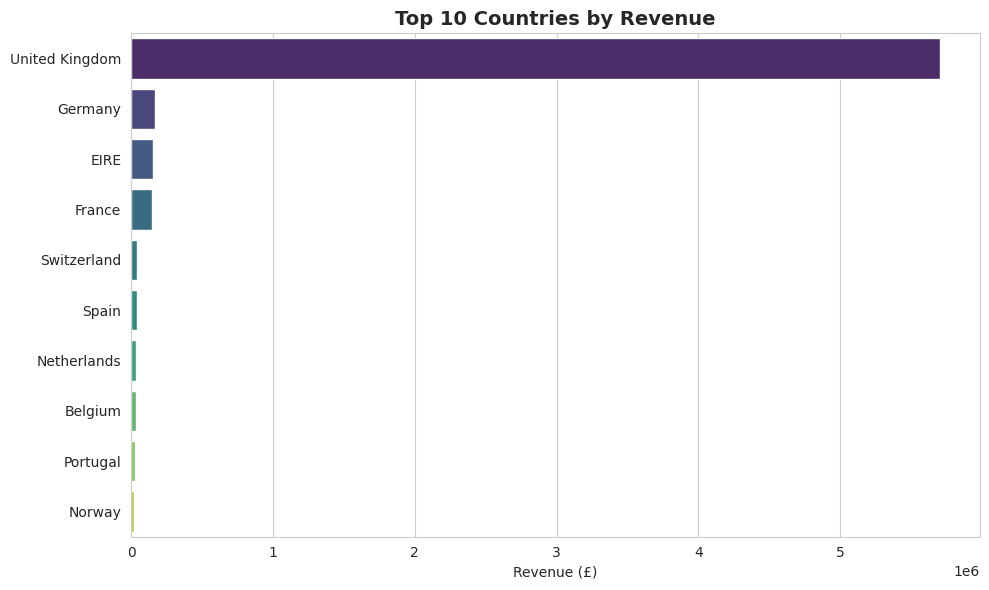

In [12]:
country_rev = df_sales.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False)
top_countries = country_rev.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette="viridis", legend=False)
plt.title("Top 10 Countries by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Revenue (£)"); plt.ylabel("")
plt.tight_layout()
plt.savefig("02_top_countries_by_revenue.png")
plt.show()

### 3. Top 10 Best-Selling Products (by Quantity)

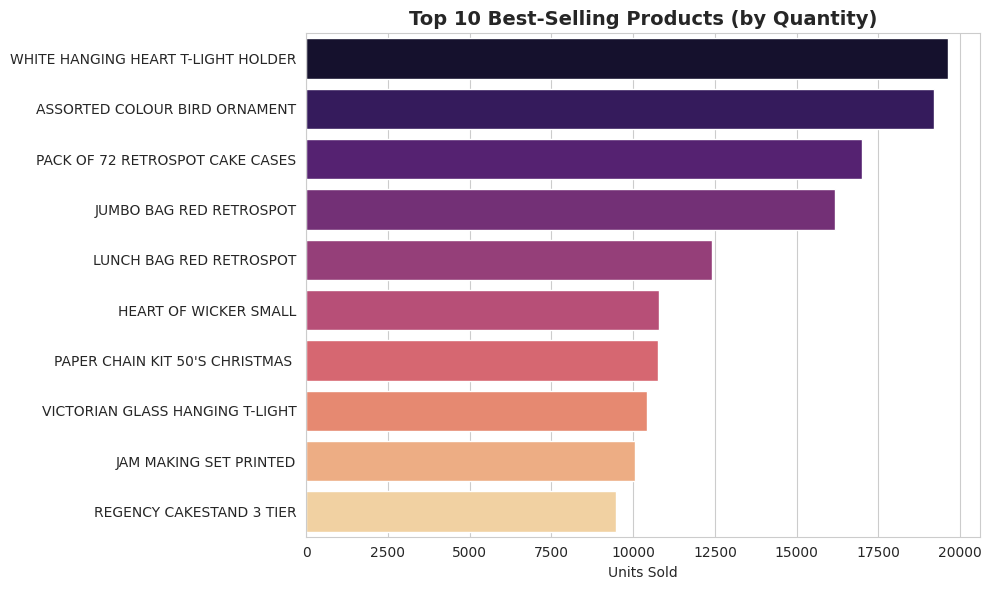

In [13]:
top_products = (df_sales.groupby("Description")["Quantity"].sum()
                 .sort_values(ascending=False).head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette="magma", legend=False)
plt.title("Top 10 Best-Selling Products (by Quantity)", fontsize=14, fontweight="bold")
plt.xlabel("Units Sold"); plt.ylabel("")
plt.tight_layout()
plt.savefig("03_top_products_by_quantity.png")
plt.show()

### 4. Order Value Distribution

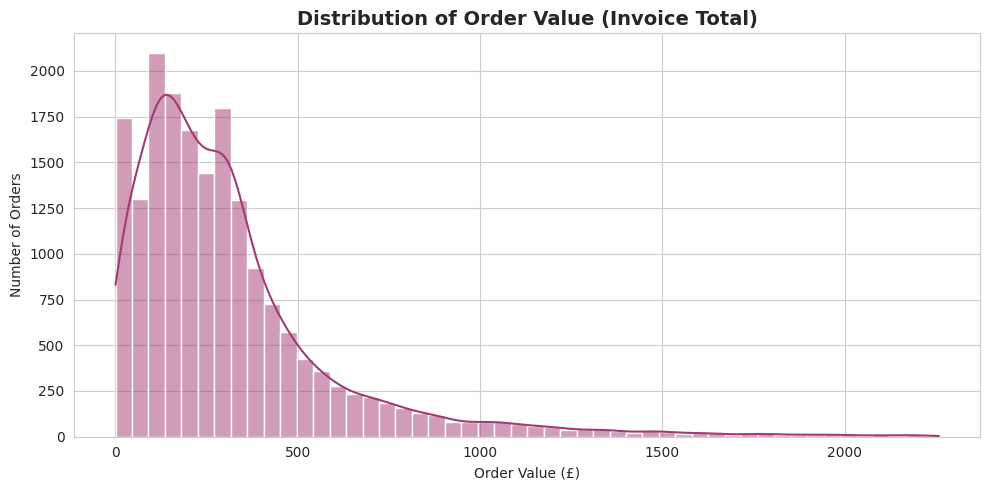

In [14]:
invoice_value = df_sales.groupby("InvoiceNo")["TotalPrice"].sum()

plt.figure(figsize=(10, 5))
sns.histplot(invoice_value[invoice_value < invoice_value.quantile(0.99)],
             bins=50, color="#A23B72", kde=True)
plt.title("Distribution of Order Value (Invoice Total)", fontsize=14, fontweight="bold")
plt.xlabel("Order Value (£)"); plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig("04_order_value_distribution.png")
plt.show()

### 5. Revenue by Day of Week

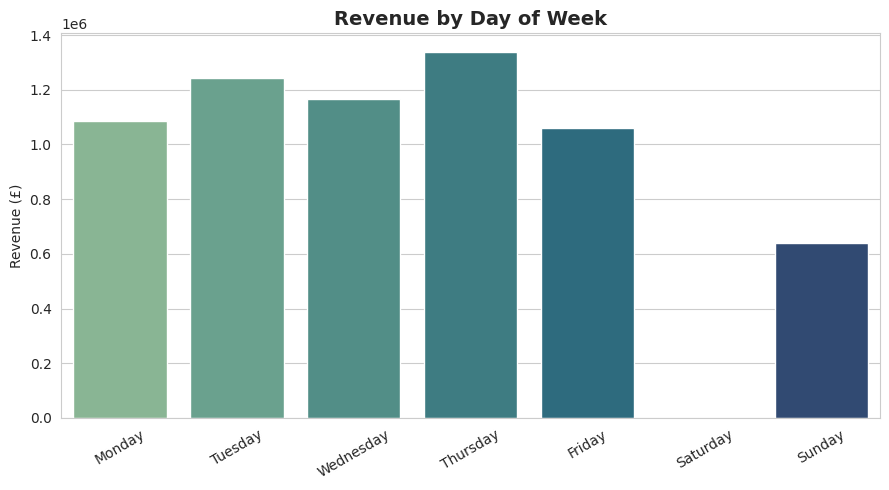

In [15]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_rev = df_sales.groupby("DayOfWeek")["TotalPrice"].sum().reindex(dow_order)

plt.figure(figsize=(9, 5))
sns.barplot(x=dow_rev.index, y=dow_rev.values, hue=dow_rev.index, palette="crest", legend=False)
plt.title("Revenue by Day of Week", fontsize=14, fontweight="bold")
plt.xlabel(""); plt.ylabel("Revenue (£)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("05_revenue_by_day_of_week.png")
plt.show()

### 6. Top 10 Customers by Total Spend (registered customers only)

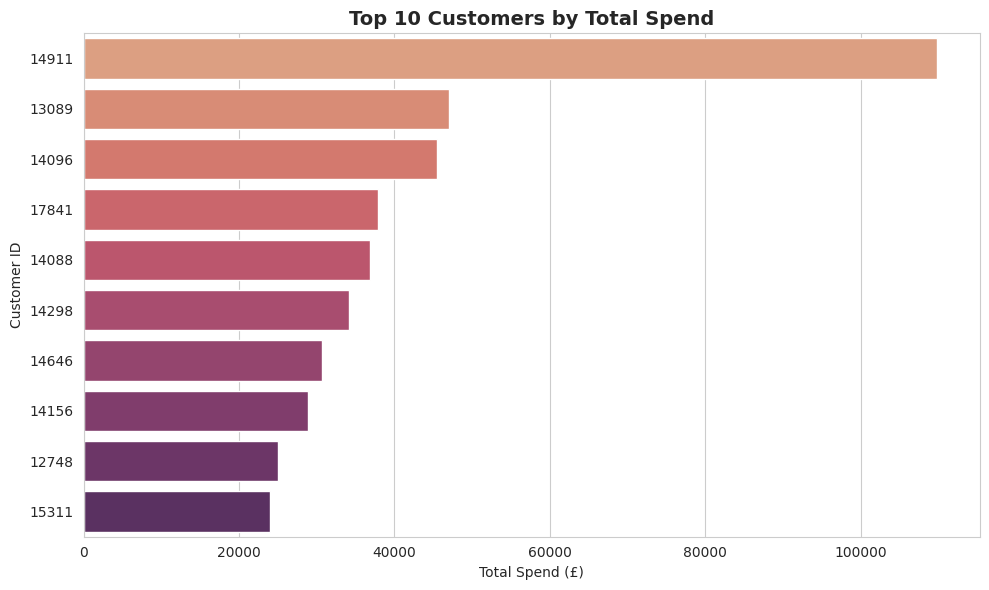

In [16]:
cust_df = df_sales.dropna(subset=["CustomerID"])
top_customers = (cust_df.groupby("CustomerID")["TotalPrice"].sum()
                  .sort_values(ascending=False).head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=top_customers.values, y=top_customers.index.astype(str),
            hue=top_customers.index.astype(str), palette="flare", legend=False)
plt.title("Top 10 Customers by Total Spend", fontsize=14, fontweight="bold")
plt.xlabel("Total Spend (£)"); plt.ylabel("Customer ID")
plt.tight_layout()
plt.savefig("06_top_customers_by_spend.png")
plt.show()

### 7. Combined Insights Dashboard

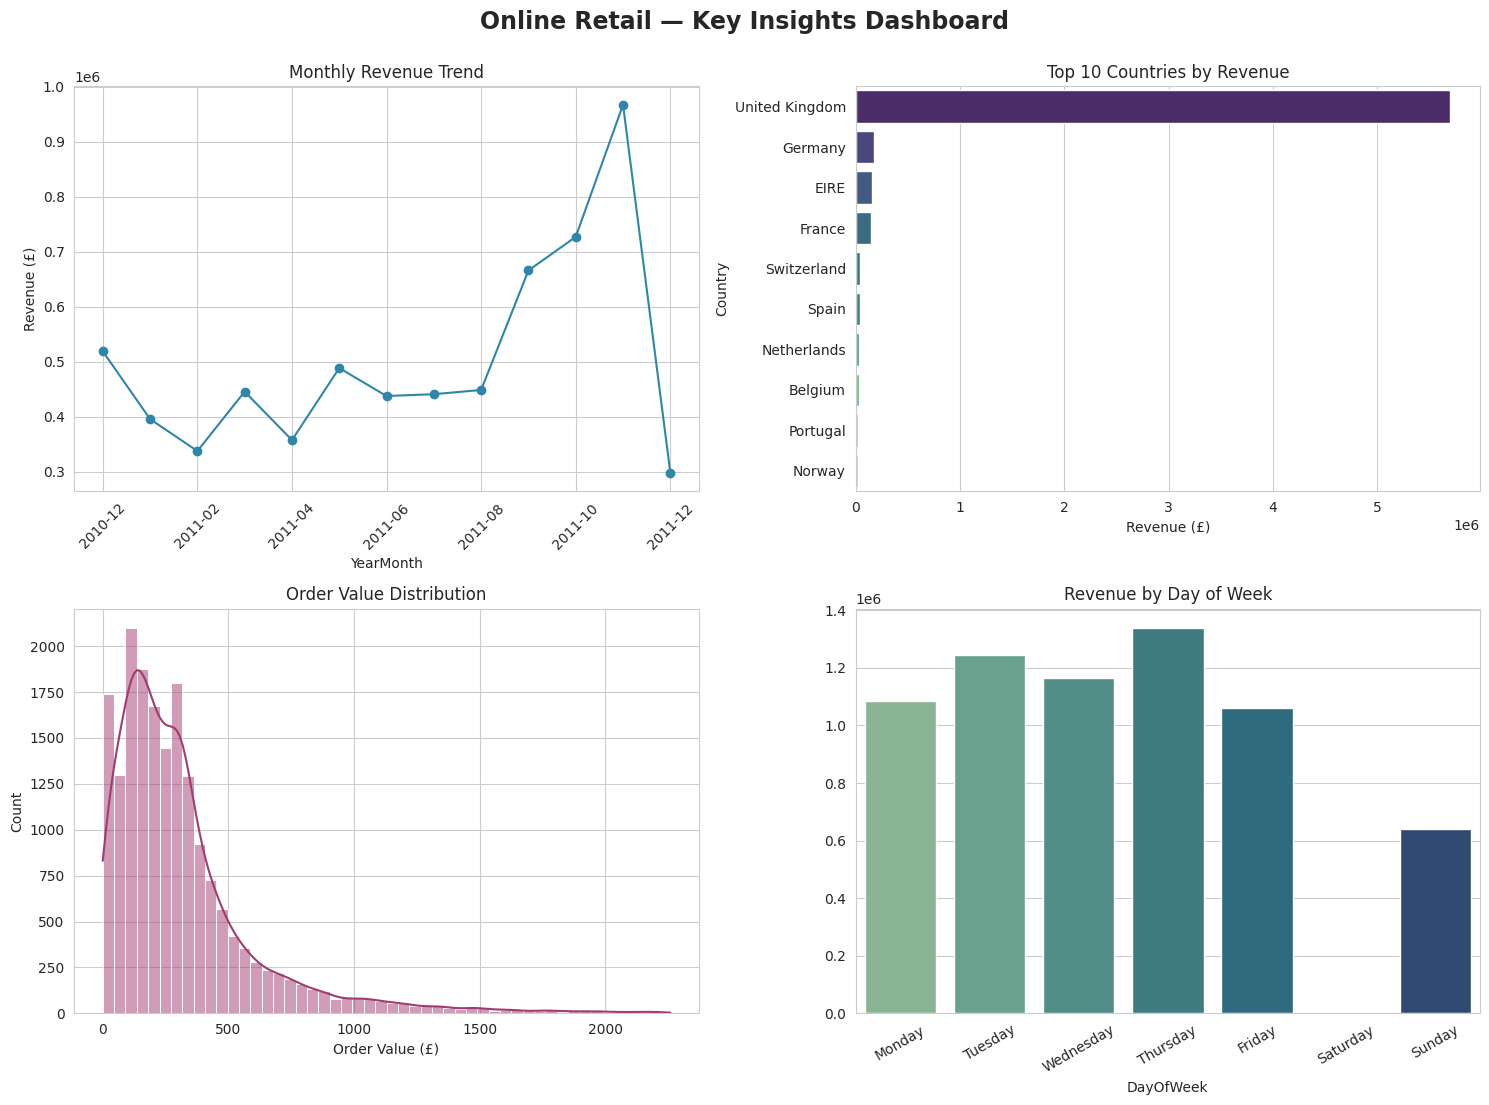

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

monthly_rev.plot(kind="line", marker="o", ax=axes[0, 0], color="#2E86AB")
axes[0, 0].set_title("Monthly Revenue Trend")
axes[0, 0].set_ylabel("Revenue (£)")
axes[0, 0].tick_params(axis="x", rotation=45)

sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index,
            palette="viridis", legend=False, ax=axes[0, 1])
axes[0, 1].set_title("Top 10 Countries by Revenue")
axes[0, 1].set_xlabel("Revenue (£)")

sns.histplot(invoice_value[invoice_value < invoice_value.quantile(0.99)],
             bins=50, color="#A23B72", kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Order Value Distribution")
axes[1, 0].set_xlabel("Order Value (£)")

sns.barplot(x=dow_rev.index, y=dow_rev.values, hue=dow_rev.index,
            palette="crest", legend=False, ax=axes[1, 1])
axes[1, 1].set_title("Revenue by Day of Week")
axes[1, 1].tick_params(axis="x", rotation=30)

fig.suptitle("Online Retail — Key Insights Dashboard", fontsize=17, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig("07_dashboard_summary.png", bbox_inches="tight")
plt.show()

## Key Findings

In [18]:
total_revenue = df_sales["TotalPrice"].sum()
n_orders = df_sales["InvoiceNo"].nunique()
n_customers = df_sales["CustomerID"].nunique()
avg_order_value = invoice_value.mean()
top_country = country_rev.index[0]
top_country_share = country_rev.iloc[0] / total_revenue * 100
best_month = monthly_rev.idxmax()

print(f"Total revenue (cleaned):     £{total_revenue:,.2f}")
print(f"Total orders:                {n_orders:,}")
print(f"Unique registered customers: {n_customers:,}")
print(f"Average order value:         £{avg_order_value:,.2f}")
print(f"Top market:                  {top_country} ({top_country_share:.1f}% of revenue)")
print(f"Best month:                  {best_month} (£{monthly_rev.max():,.0f})")
print(f"Cancellation rate:           {len(cancellations)/len(df)*100:.1f}% of raw rows")

Total revenue (cleaned):     £6,533,821.71
Total orders:                18,670
Unique registered customers: 4,234
Average order value:         £349.96
Top market:                  United Kingdom (87.3% of revenue)
Best month:                  2011-11 (£967,233)
Cancellation rate:           1.7% of raw rows


## Summary

- Cleaned dataset retains ~91% of raw rows after removing duplicates, cancellations, invalid rows, and extreme outliers.
- UK accounts for the vast majority of revenue (concentration risk worth flagging to the business).
- Revenue peaks sharply in November (holiday gift-buying season) then drops off in the partial December data.
- Order values are heavily right-skewed — most orders are small, with a long tail of bulk/wholesale orders.

**Possible extensions:** RFM customer segmentation, cohort/retention analysis, market basket analysis (association rules), time-series forecasting for next quarter's revenue.